In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# 1) Install + imports
!pip install xgboost -q

import pandas as pd
import numpy as np
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split

# 2) Mount Drive
from google.colab import drive
drive.mount('/content/drive')

# 3) Load merged fundus CSV
csv_path = "/content/drive/MyDrive/Colab Notebooks/fundus_project/outputs/merged_fundus_features.csv"
df = pd.read_csv(csv_path)

print("DF shape:", df.shape)

# 4) Map string labels -> numbers
# Label mapping:
# hr -> 0, myopia -> 1, normal -> 2, rp -> 3
label_map = {"hr": 0, "myopia": 1, "normal": 2, "rp": 3}

# use the column that has hr/myopia/normal/rp (change if different)
RAW_LABEL_COL = "label_name"   # <-- change if your label column name is "label" etc.
df["label_id"] = df[RAW_LABEL_COL].map(label_map)

TARGET_COL = "label_id"
y = df[TARGET_COL]

# 5) Drop non-feature / meta columns
meta_cols = [
    "image_path",
    "image_id",
    "split",
    "label_name",
    "model_arch",
    "checkpoint_path",
    "split_clinical",
    "split_generic",
    TARGET_COL
]

# keep only existing columns from this list
meta_cols = [c for c in meta_cols if c in df.columns]

X = df.drop(columns=meta_cols)

# keep only numeric features (xgboost requirement)
X = X.select_dtypes(include=[np.number])

print("Feature matrix shape:", X.shape)

# 6) Train / test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 7) Train XGBoost model
model = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="multi:softprob",
    eval_metric="mlogloss",
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

# 8) Get top features
importances = model.feature_importances_
feat_names = np.array(X.columns)

sorted_idx = np.argsort(importances)[::-1]
top_n = 30  # change if you want

print("\nTop features by XGBoost:\n")
for rank, idx in enumerate(sorted_idx[:top_n], start=1):
    print(f"{rank:2d}. {feat_names[idx]}  ->  {importances[idx]:.4f}")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
DF shape: (5555, 640)
Feature matrix shape: (5555, 631)

Top features by XGBoost:

 1. emb_151  ->  0.1562
 2. emb_166  ->  0.0960
 3. emb_041  ->  0.0920
 4. emb_019  ->  0.0539
 5. emb_190  ->  0.0430
 6. emb_490  ->  0.0415
 7. emb_456  ->  0.0367
 8. label_idx  ->  0.0321
 9. emb_432  ->  0.0245
10. emb_332  ->  0.0217
11. emb_386  ->  0.0206
12. emb_377  ->  0.0201
13. emb_100  ->  0.0163
14. emb_372  ->  0.0161
15. emb_227  ->  0.0151
16. emb_280  ->  0.0094
17. emb_410  ->  0.0084
18. emb_110  ->  0.0079
19. emb_210  ->  0.0069
20. emb_314  ->  0.0068
21. emb_327  ->  0.0068
22. emb_396  ->  0.0067
23. emb_148  ->  0.0053
24. emb_355  ->  0.0053
25. emb_487  ->  0.0051
26. emb_484  ->  0.0048
27. emb_117  ->  0.0047
28. emb_322  ->  0.0047
29. image_entropy_global  ->  0.0042
30. emb_334  ->  0.0040


In [ ]:
# ========= GLOBAL clinical feature importance (fresh tab) =========
import os, numpy as np, pandas as pd, joblib, torch, torch.nn as nn
import torch.nn.functional as F

# -------- PATHS --------
MERGED_CSV  = "/content/drive/MyDrive/Colab Notebooks/fundus_project/outputs/merged_fundus_features.csv"
EXP_DIR     = "/content/drive/MyDrive/Colab Notebooks/fundus_project/outputs/fundus_training_runs/exp_20251104_152240"
FCNN_CKPT   = os.path.join(EXP_DIR, "fold2_FCNN_deep/FCNN_deep_fold2_best.pth")
SCALER_PATH = os.path.join(EXP_DIR, "scaler.joblib")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# -------- LOAD DATA --------
df = pd.read_csv(MERGED_CSV, low_memory=False)

df = df[~df['label_idx'].isna()].reset_index(drop=True)
df['label_idx'] = df['label_idx'].astype(int)

# same feature logic as training
emb_cols = [c for c in df.columns if c.startswith("emb_")]
exclude_cols = set(['image_path','image_id','checkpoint_path','label_name','split'])
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
extra_numeric = [c for c in numeric_cols if (c not in emb_cols and c!='label_idx')]
FEATURE_COLS = emb_cols + extra_numeric

emb_dim  = len(emb_cols)
clin_dim = len(extra_numeric)
input_dim = emb_dim + clin_dim

print(f"Emb: {emb_dim}, Clinical: {clin_dim}, Total: {input_dim}")

# -------- PREPROCESS FEATURES --------
X_df = df[FEATURE_COLS].copy()
X_df.replace([np.inf, -np.inf], np.nan, inplace=True)
X_df = X_df.fillna(X_df.mean()).fillna(0.0)
X_df = X_df.replace([np.inf, -np.inf], 0.0)

scaler = joblib.load(SCALER_PATH)
X_all = scaler.transform(X_df.values)

# test subset
if 'split' in df.columns:
    mask = (df['split'] == 'test')
else:
    mask = np.ones(len(df), dtype=bool)

X_test = X_all[mask]
y_test = df.loc[mask, 'label_idx'].values

print("Test samples:", X_test.shape[0])

# -------- FCNN MODEL (same arch) --------
class FCNN_deep(nn.Module):
    def __init__(self, input_dim, num_classes=4):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, 2048)
        self.bn1 = nn.BatchNorm1d(2048)
        self.fc2 = nn.Linear(2048, 1024)
        self.fc3 = nn.Linear(1024, 512)
        self.out = nn.Linear(512, num_classes)
        self.drop = nn.Dropout(0.4)
    def forward(self, x):
        x = F.relu(self.bn1(self.fc1(x)))
        x = self.drop(x)
        x = F.relu(self.fc2(x))
        x = self.drop(x)
        x = F.relu(self.fc3(x))
        x = self.drop(x)
        return self.out(x)

fcnn = FCNN_deep(input_dim).to(device)
fcnn.load_state_dict(torch.load(FCNN_CKPT, map_location=device))
fcnn.eval()
print("Loaded FCNN")

# -------- GRADIENT-BASED IMPORTANCE --------
clin_importance = np.zeros(clin_dim, dtype=np.float64)

N = min(500, X_test.shape[0])   # increase if you want more stability
print("Computing importance on", N, "samples")

for i in range(N):
    x = torch.tensor(X_test[i:i+1], dtype=torch.float32,
                     device=device, requires_grad=True)
    out = fcnn(x)
    cls = int(torch.argmax(out, dim=1))
    score = out[0, cls]

    fcnn.zero_grad()
    score.backward()

    grads = x.grad.detach().cpu().numpy().squeeze()
    clin_grads = grads[emb_dim:]
    clin_importance += np.abs(clin_grads)

clin_importance /= N

# -------- PRINT TOP FEATURES --------
sorted_idx = np.argsort(clin_importance)[::-1]
top_k = 30

print("\n==== TOP Clinical / Handcrafted Features (FCNN) ====\n")
for r in range(top_k):
    j = sorted_idx[r]
    print(f"{r+1:2d}. {extra_numeric[j]}  ->  {clin_importance[j]:.6f}")


Device: cpu
Emb: 512, Clinical: 118, Total: 630
Test samples: 1027
Loaded FCNN
Computing importance on 500 samples

==== TOP Clinical / Handcrafted Features (FCNN) ====

 1. vein_density  ->  0.297016
 2. vein_density_generic  ->  0.296476
 3. vessel_density  ->  0.291232
 4. hard_exudate_max_area  ->  0.207996
 5. illumination_gradient_y_generic  ->  0.203024
 6. hard_exudate_max_area_generic  ->  0.202855
 7. illumination_gradient_y  ->  0.201820
 8. illumination_gradient_x  ->  0.185545
 9. illumination_gradient_x_generic  ->  0.182749
10. branch_point_count  ->  0.159490
11. peripheral_pigmentation_index_generic  ->  0.158495
12. branch_point_count_generic  ->  0.158458
13. peripheral_pigmentation_index  ->  0.156760
14. vascular_complexity_ratio_generic  ->  0.150180
15. lesion_count_generic  ->  0.147255
16. macular_entropy  ->  0.141833
17. lesion_count  ->  0.137787
18. vascular_complexity_ratio  ->  0.136485
19. tortuosity_to_vessel_ratio  ->  0.125761
20. CRAE  ->  0.116171
2

In [ ]:
# ==== 1) Install + imports ====
!pip install xgboost -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from xgboost import XGBClassifier
from google.colab import drive

# ==== 2) Mount Drive ====
drive.mount('/content/drive')

# ==== 3) Load merged fundus CSV ====
csv_path = "/content/drive/MyDrive/Colab Notebooks/fundus_project/outputs/merged_fundus_features.csv"
df = pd.read_csv(csv_path, low_memory=False)
print("Shape:", df.shape)

# ==== 4) Target (use label_idx if available) ====
if "label_idx" in df.columns:
    y = df["label_idx"].astype(int)
else:
    label_col = "label_name" if "label_name" in df.columns else "label"
    label_map = {name: i for i, name in enumerate(sorted(df[label_col].unique()))}
    print("Label mapping:", label_map)
    y = df[label_col].map(label_map).astype(int)
    df["label_idx"] = y

# ==== 5) Select ONLY clinical/handcrafted numeric features ====
emb_cols = [c for c in df.columns if c.startswith("emb_")]
exclude_cols = set([
    'image_path', 'image_id', 'checkpoint_path',
    'label_name', 'label', 'label_idx',
    'split', 'model_arch', 'split_clinical', 'split_generic'
])

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
clin_cols = [c for c in numeric_cols if (c not in emb_cols and c not in exclude_cols)]

print("Clinical/handcrafted feature count:", len(clin_cols))
X = df[clin_cols].copy()

# Clean inf / NaN
X = X.replace([np.inf, -np.inf], np.nan)
mask = ~X.isna().any(axis=1)
X = X[mask]
y = y[mask]
print("After cleaning:", X.shape)

# ==== 6) Train XGBoost on clinical/handcrafted features ====
model = XGBClassifier(
    n_estimators=400,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="multi:softprob",
    eval_metric="mlogloss",
    random_state=42,
    n_jobs=-1
)
model.fit(X, y)

# ==== 7) Get top features + GRAPH (bar chart) ====
importances = model.feature_importances_
feat_names = np.array(clin_cols)

sorted_idx = np.argsort(importances)[::-1]
top_n = 20   # change if you want more/less
top_feats = feat_names[sorted_idx][:top_n]
top_imps  = importances[sorted_idx][:top_n]

print("Top clinical/handcrafted features:\n")
for i, (f, imp) in enumerate(zip(top_feats, top_imps), start=1):
    print(f"{i:2d}. {f} -> {imp:.4f}")

# bar graph
plt.figure(figsize=(8, 6))
plt.barh(range(len(top_feats)), top_imps[::-1])
plt.yticks(range(len(top_feats)), top_feats[::-1])
plt.xlabel("XGBoost importance")
plt.title(f"Top {top_n} clinical/handcrafted features")
plt.tight_layout()
plt.show()


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Shape: (5555, 640)
Clinical/handcrafted feature count: 118
After cleaning: (0, 118)


XGBoostError: value 0 for Parameter num_class should be greater equal to 1
num_class: Number of output class in the multi-class classification.

Shape: (5555, 640)
Clinical/handcrafted feature count: 118
X shape: (5555, 118)  y shape: (5555,)

Top clinical/handcrafted features (XGBoost global importance):

 1. width_generic  ->  0.2225
 2. width  ->  0.1024
 3. height  ->  0.0768
 4. color_balance_ratio  ->  0.0450
 5. height_generic  ->  0.0374
 6. branch_point_count  ->  0.0260
 7. branch_point_count_generic  ->  0.0235
 8. brightness_entropy_ratio  ->  0.0174
 9. R_minus_G_mean  ->  0.0150
10. image_entropy_global_generic  ->  0.0141


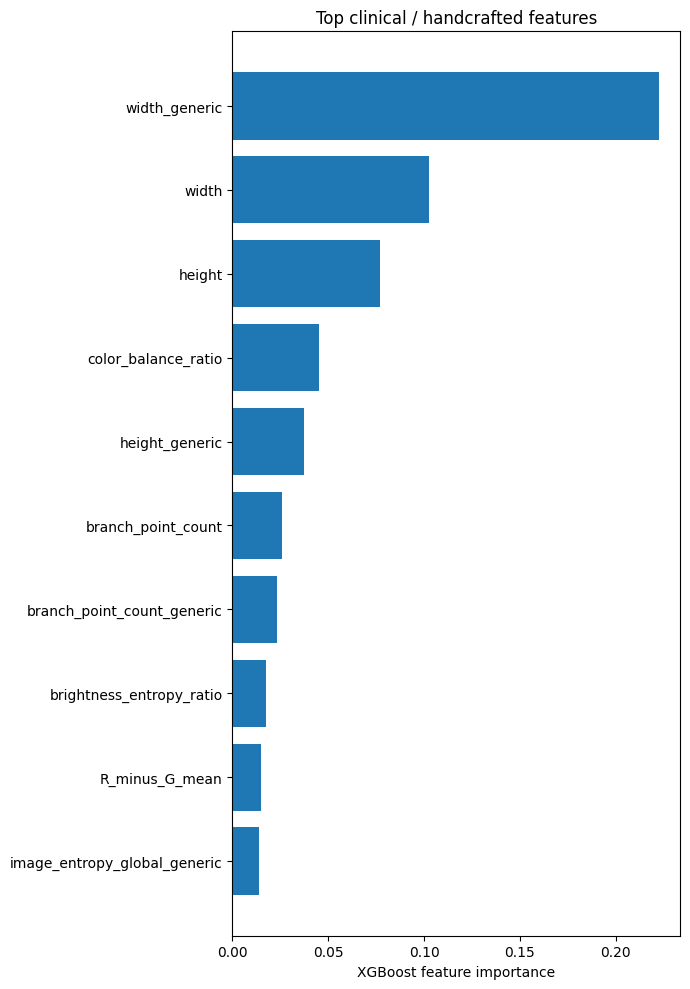

In [ ]:
# === 1) Install + imports ===
!pip install xgboost -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from xgboost import XGBClassifier

# === 2) Load merged CSV ===
csv_path = "/content/drive/MyDrive/Colab Notebooks/fundus_project/outputs/merged_fundus_features.csv"
df = pd.read_csv(csv_path, low_memory=False)
print("Shape:", df.shape)

# === 3) Make sure we have numeric labels (0=hr,1=myopia,2=normal,3=rp) ===
if "label_idx" not in df.columns:
    label_map = {"hr":0, "myopia":1, "normal":2, "rp":3}
    df["label_idx"] = df["label_name"].map(label_map)

df = df[~df["label_idx"].isna()].copy()
df["label_idx"] = df["label_idx"].astype(int)

# === 4) Pick ONLY clinical/handcrafted features (no emb_ & no meta cols) ===
emb_cols = [c for c in df.columns if c.startswith("emb_")]
exclude_cols = set([
    "image_path","image_id","checkpoint_path","label_name","label_idx",
    "split","model_arch","split_clinical","split_generic"
])

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
clin_cols = [
    c for c in numeric_cols
    if c not in emb_cols and c not in exclude_cols
]

print("Clinical/handcrafted feature count:", len(clin_cols))

X = df[clin_cols].copy()
y = df["label_idx"].values

# === 5) Clean NaNs / inf but DON'T drop rows ===
X.replace([np.inf, -np.inf], np.nan, inplace=True)
X = X.fillna(X.mean()).fillna(0.0)

print("X shape:", X.shape, " y shape:", y.shape)

# === 6) Train XGBoost only on clinical/handcrafted features ===
model = XGBClassifier(
    n_estimators=400,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="multi:softprob",
    eval_metric="mlogloss",
    num_class=4,
    random_state=42,
    n_jobs=-1
)
model.fit(X, y)

# === 7) Get top features + GRAPH (bar chart) ===
importances = model.feature_importances_
feat_names = np.array(clin_cols)

sorted_idx = np.argsort(importances)[::-1]
top_n = 10  # change if you want
top_feats = feat_names[sorted_idx[:top_n]]
top_imps = importances[sorted_idx[:top_n]]

print("\nTop clinical/handcrafted features (XGBoost global importance):\n")
for i, (f, imp) in enumerate(zip(top_feats, top_imps), start=1):
    print(f"{i:2d}. {f}  ->  {imp:.4f}")

# === 8) Plot bar graph ===
plt.figure(figsize=(7, 10))
plt.barh(range(len(top_feats)), top_imps[::-1])
plt.yticks(range(len(top_feats)), top_feats[::-1])
plt.xlabel("XGBoost feature importance")
plt.title("Top clinical / handcrafted features")
plt.tight_layout()
plt.show()
